# MVP — Machine Learning & Analytics

**Nome:** _Marcela Stein_  
**Matrícula:** 4052025002184  
**Data:** _03/07/2026_  
**Dataset:**

_[API_MS.MIL.MPRT.KD_DS2](https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_MS.MIL.MPRT.KD_DS2_en_csv_v2_283802.csv)_

_[API_MS.MIL.TOTL.P1_DS2](https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_MS.MIL.TOTL.P1_DS2_en_csv_v2_115556.csv)_

_[API_MS.MIL.XPND.CD_DS2](https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_MS.MIL.XPND.CD_DS2_en_csv_v2_280448.csv)_

_[API_MS.MIL.XPRT.KD_DS2](https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_MS.MIL.XPRT.KD_DS2_en_csv_v2_175.csv)_

_[API_NY.GDP.MKTP.CD_DS2](https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_280770.csv)_

_[API_SL.TLF.TOTL.IN_DS2](https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_SL.TLF.TOTL.IN_DS2_en_csv_v2_280800.csv)_

_[UcdpPrioConflict_v26_1](https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/UcdpPrioConflict_v26_1.csv)_

 **Tipo de problema:** _Classificação com dados temporais



# 1. Definição do problema

## 1.1 Descrição do problema

Em um cenário internacional marcado por diversos conflitos entre países, o governo brasileiro e as forças armadas precisam acompanhar constantemente a evolução das tensões geopolíticas ao redor do mundo. Além dos impactos humanitários, os conflitos geram consequências significativas para a economia, a política e a segurança internacional. Nesse contexto, a utilização de um modelo que auxilie na predição de quais países podem estar futuramente envolvidos em conflitos pode contribuir para uma melhor tomada de decisão, apoiando ações de prevenção, monitoramento e planejamento estratégico.

Considerando esse cenário, o modelo desenvolvido nesse trabalho será tratado como um modelo de classificação, na qual deverá indicar se um país possui ou não probabilidade de estar envolvido em um conflito no ano seguinte.

A relevância do problema está relacionada à necessidade de compreender melhor os fatores que antecedem os conflitos e fornecer informações que apoiem decisões voltadas à segurança, estabilidade e defesa do Estado.



## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  

O objetivo deste MVP é analisar se informações relacionadas à capacidade militar de um país podem ajudar a prever sua participação em conflitos no ano seguinte. Para isso, serão utilizados dados históricos de 1960 a 2025, como gastos militares, efetivo das forças armadas, PIB, entre outros.

A previsão será realizada por meio de modelos de classificação de *Machine Learning*, cujo objetivo será indicar se um país possui ou não chances de estar envolvido em um conflito no período seguinte. Para a construção do modelo preditivo, o trabalho irá buscar comparar diferentes algoritmos de classificação para identificar aquele que apresenta o melhor desempenho. A seleção do modelo mais adequado permitirá obter resultados mais confiáveis e robustos, aumentando a segurança das previsões realizadas para dados futuros e fornecendo maior suporte à tomada de decisão.



## 1.3 Tipo de problema

**Tipo escolhido:** Cassificação com dados temporais  
**Justificativa:** O problema é considerado de classificação (binária), na qual o objetivo é prever a ocorrência de conflito em um país no período subsequente. Se houver conflito no t+1 será representado por um, caso contrário será zero. Embora a variável resposta seja categórica, os dados possuem estrutura temporal.



## 1.4 Premissas, hipóteses e critérios de sucesso


**Hipóteses iniciais:**
1. _Indicadores relacionados à capacidade militar dos países, como gastos militares, efetivo das forças armadas, importação e exportação de armamentos, possuem relação com a ocorrência de conflitos e podem ser utilizados para prever a participação de um país em conflitos no ano seguinte._
2. _Modelos de Machine Learning são capazes de identificar padrões nos dados históricos e apresentar desempenho superior a uma classificação aleatória ou a um modelo baseline simples._
3. _Algoritmos mais robustos, como Random Forest e XGBoost, apresentarão melhor desempenho preditivo do que modelos mais simples, como SVM._

**Critérios de sucesso:**
- Métrica principal: _F1-score, Recall e Precisão._
- Resultado mínimo esperado:  _superar o baseline em pelo menos 10%._
- Restrição prática: _dados desbalanceados._




# 2. Ambiente, bibliotecas e reprodutibilidade




In [49]:
#Bibliotécas utilizadas

# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.model_selection import train_test_split,  GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,  MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)

from scipy.stats import randint

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais




In [2]:
!pip install pycountry pycountry_convert # identificação de países
!pip install -q xgboost # modelo utilizado na análise
import pycountry
import pycountry_convert as pc
from xgboost import XGBClassifier


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.3/255.3 kB 22.8 MB/s eta 0:00:00


## 2.2 Funções auxiliares


In [3]:
def limpar_governo(texto):
    """
    Limpar o texto, tirando espaços extras, tirando palavras com parênteses, tirando
    "Government of" e transformando alguns países na configurações correta
    """

    if pd.isna(texto):
        return None

    if "Government of" not in texto:
        return None

    # Remove "Government of"
    texto = re.sub(
        r"Government of\s+",
        "",
        texto,
        flags=re.IGNORECASE
    )

    texto = re.sub(
    r"dr\s+",
    "",
    texto,
    flags=re.IGNORECASE
    )
    # Correções específicas
    texto = texto.replace("South Vietnam", "Vietnam")
    texto = texto.replace("North Vietnam", "Vietnam")
    texto = texto.replace("South Yemen", "Yemen")
    texto = texto.replace("North Yemen", "Yemen")
    texto = texto.replace("Bosnia-Herzegovina", "Bosnia and Herzegovina")
    texto = texto.replace("Turkey", "Türkiye")
    texto = texto.replace("Czechoslovakia", "Czechia")
    # Remove tudo entre parênteses
    texto = re.sub(
        r"\(.*?\)",
        "",
        texto
    )

    # Remove espaços extras
    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto

def obter_continente(codigo_iso3):
    """
    Obter os códigos dos países
    """
    excecoes = {
        "TLS": "Asia",               # Timor-Leste
        "SXM": "America do Norte"    # Sint Maarten (Dutch part)
    }

    if codigo_iso3 in excecoes:
        return excecoes[codigo_iso3]
    try:
        codigo_iso2 = pc.country_alpha3_to_country_alpha2(codigo_iso3)
        continente_cod = pc.country_alpha2_to_continent_code(codigo_iso2)

        continentes = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europa",
            "NA": "America do Norte",
            "SA": "America do Sul",
            "OC": "Oceania"
        }

        return continentes.get(continente_cod)

    except:
        return None


def evaluate_classification( y_true,  y_pred,  proba=None ):
    """
    Avalia modelos de classificação com foco em
    problemas desbalanceados.
    """

    results = {

        "precision":
            precision_score(y_true, y_pred, zero_division=0),

        "recall":
            recall_score(y_true, y_pred, zero_division=0),

        "f1":
            f1_score(y_true, y_pred,zero_division=0),
    }

    try:

        if (proba is not None and proba.shape[1] == 2):
            results["roc_auc"] = (roc_auc_score( y_true,proba[:, 1])
            )

        else:
            results["roc_auc"] = np.nan

    except Exception:
        results["roc_auc"] = np.nan

    return results



def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Para o desenvolvimento deste trabalho, foram selecionados sete *datasets*. Seis deles correspondem a indicadores obtidos no site do World Bank Group (https://data.worldbank.org/indicator). Os indicadores utilizados foram: *Arms imports* (API_MS.MIL.MPRT.KD), *Armed forces personnel, total* (API_MS.MIL.TOTL.P1), *Military expenditure (current USD)* (API_MS.MIL.XPND.CD), *Arms exports* (API_MS.MIL.XPRT.KD), *GDP (current USD)* (API_NY.GDP.MKTP.CD) e *Labor force, total* (API_SL.TLF.TOTL.IN). Esses indicadores foram selecionados por fornecerem informações relevantes sobre a capacidade militar e a situação econômica dos países.

O sétimo *dataset* foi disponibilizado pela Uppsala University (https://ucdp.uu.se/downloads/#section-yearly-1946). Esse conjunto de dados reúne todos os conflitos ocorridos entre 1946 e 2025, informando os países e grupos envolvidos, bem como o lado ao qual pertenciam em cada conflito. Esse *dataset* é fundamental para o problema de classificação, pois, a partir dessas informações, é possível identificar se um país estava em conflito no ano *t+1*, considerando *t* como o ano corrente.

Foi necessário realizar uma etapa de pré-processamento para integrar todos os *datasets* selecionados em uma única base de dados.



## 3.2 Carga dos dados




####3.2.1 Abrir os Dataset

In [4]:
#Abrir os arquivos dos dados dos países
df_Armas_importação = pd.read_csv("https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_MS.MIL.MPRT.KD_DS2_en_csv_v2_283802.csv",skiprows=4,sep=",")
df_pessoal_militar = pd.read_csv("https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_MS.MIL.TOTL.P1_DS2_en_csv_v2_115556.csv",skiprows=4,sep=",")
df_gastos_militar = pd.read_csv("https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_MS.MIL.XPND.CD_DS2_en_csv_v2_280448.csv",skiprows=4,sep=",")
df_armas_exportação = pd.read_csv("https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_MS.MIL.XPRT.KD_DS2_en_csv_v2_175.csv",skiprows=4,sep=",")
df_pib = pd.read_csv("https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_280770.csv",skiprows=4,sep=",")
df_forca_de_trabalho = pd.read_csv("https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/API_SL.TLF.TOTL.IN_DS2_en_csv_v2_280800.csv",skiprows=4,sep=",")
#Abrir arquivo dos conflitos mudiais
df_conflitos = pd.read_csv("https://raw.githubusercontent.com/marcelastein/MVP-Classificacao_conflitos_militares/main/UcdpPrioConflict_v26_1.csv",sep=",")

#### 3.2.2 Incluir todos os dataset de indicadores em um único dataframe

In [5]:
#Eliminar colunas desnecessárias dos arquivos dos indicadores
df_Armas_importação = df_Armas_importação.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"])
df_pessoal_militar = df_pessoal_militar.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"])
df_gastos_militar = df_gastos_militar.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"])
df_armas_exportação = df_armas_exportação.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"])
df_pib = df_pib.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"])
df_forca_de_trabalho = df_forca_de_trabalho.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"])

df_forca_de_trabalho

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,245924910.0,251170980.0,257765403.0,264515662.0,268425249.0,277268587.0,287406365.0,286716203.0,290536403.0,299259550.0
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8883595.0,9223903.0,9215046.0,9192643.0,9060510.0,9128262.0,8617545.0,8846502.0,9145340.0,9433041.0
3,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,175381549.0,179638384.0,184477200.0,189456579.0,191755366.0,199049398.0,207075183.0,215067825.0,221658072.0,228165613.0
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12119717.0,12515803.0,12917977.0,13331298.0,13484525.0,14529142.0,14812783.0,15255232.0,15787244.0,16321277.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6044703.0,6279018.0,6505806.0,6735232.0,6884754.0,7037044.0,7408746.0,7664536.0,7928543.0,8155939.0
263,South Africa,ZAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22454382.0,22888401.0,23325105.0,23899064.0,22347803.0,23480812.0,24587967.0,25707269.0,26362253.0,26731522.0
264,Zambia,ZMB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5472448.0,5669282.0,5870382.0,6200188.0,6574250.0,6728077.0,6905885.0,7453413.0,7724343.0,8011366.0


In [6]:
#Ajustar cada dataframe para ter uma coluna com os anos e outra coluna com os respectivos valores por ano para cada país
df_long_armas_importação = df_Armas_importação.melt(id_vars=["Country Name","Country Code"],var_name="Ano",value_name="Armas Importação")
df_long_pessoal_militar = df_pessoal_militar.melt(id_vars=["Country Name","Country Code"],var_name="Ano",value_name="Pessoal Militar")
df_long_gastos_militar = df_gastos_militar.melt(id_vars=["Country Name","Country Code"],var_name="Ano",value_name="Gastos Militar")
df_long_armas_exportação = df_armas_exportação.melt(id_vars=["Country Name","Country Code"],var_name="Ano",value_name="Armas Exportação")
df_long_pib = df_pib.melt(id_vars=["Country Name","Country Code"],var_name="Ano",value_name="PIB")
df_long_forca_de_trabalho = df_forca_de_trabalho.melt(id_vars=["Country Name","Country Code"],var_name="Ano",value_name="Força de Trabalho")


In [7]:
#Unir as tabelas
df_base = df_long_gastos_militar.merge(df_long_armas_importação,on=["Country Name","Country Code", "Ano"], how="outer")

df_base = df_base.merge(df_long_armas_exportação,on=["Country Name","Country Code", "Ano"], how="outer")

df_base = df_base.merge(df_long_pessoal_militar,on=["Country Name","Country Code", "Ano"], how="outer")

df_base = df_base.merge(df_long_forca_de_trabalho,on=["Country Name","Country Code", "Ano"], how="outer")

df_base = df_base.merge(df_long_pib,on=["Country Name","Country Code", "Ano"], how="outer")


In [8]:
#Ajustar para deixar apenas os países (ex, tirar world)
codigos_paises = {pais.alpha_3 for pais in pycountry.countries}
df_base = df_base[df_base["Country Code"].isin(codigos_paises)]
# Trasformar a coluna Ano em número
df_base["Ano"] = df_base["Ano"].astype(int)


#### 3.2.3 Ajustar o dataframe dos conflitos

In [9]:
#Manter apenas conflitos de 1961+
df_conflitos = df_conflitos[df_conflitos["year"] >= 1961]

In [10]:
# Manter apenas linhas com Government no lado a e (b ou b2)
df_conflitos = df_conflitos[
    df_conflitos["side_a"].str.contains("government", case=False, na=False) &
    df_conflitos["side_b"].str.contains("government", case=False, na=False)|
    df_conflitos["side_b_2nd"].str.contains("government", case=False, na=False)]

In [11]:
#Criar um dataframe limpo
df_conflito_limpo = pd.DataFrame()
#Incluindo informações no dataframe limpo. Em alguns casos usa-se a função "limpar_governo" para deixar as informações mais adequadas para serem processadas
df_conflito_limpo['Ano'] = df_conflitos['year']
df_conflito_limpo["side_a"] = df_conflitos["side_a"].apply(limpar_governo).str.split(",")
df_conflito_limpo["side_a_2nd"] = df_conflitos["side_a_2nd"].apply(limpar_governo).str.split(",")
df_conflito_limpo["side_b"] = df_conflitos["side_b"].apply(limpar_governo).str.split(",")
df_conflito_limpo["side_b_2nd"] = df_conflitos["side_b_2nd"].apply(limpar_governo).str.split(",")


In [12]:
# Se tiver mais de um país na linha da coluna analisada será criada mais linhas para separar esses países
df_conflito_limpo = df_conflito_limpo.explode("side_a")
df_conflito_limpo = df_conflito_limpo.explode("side_a_2nd")
df_conflito_limpo = df_conflito_limpo.explode("side_b")
df_conflito_limpo = df_conflito_limpo.explode("side_b_2nd")

In [13]:
# Colocar os dodos dos países em uma única coluna
df_long_conflitos = df_conflito_limpo.melt(id_vars="Ano",var_name="side",value_name="Países")
#elimina espaço inicial no texto
df_long_conflitos["Países"] = df_long_conflitos["Países"].str.lstrip()
#eliminar as colunas dos paises com nan
df_conflitos_final = df_long_conflitos.loc[df_long_conflitos["Países"].notna()]
#excluir a coluna side
df_conflitos_final=df_conflitos_final.drop(columns=["side"])

#Eliminar linhas duplicadas, contendo as mesmas informações
df_conflitos_final=df_conflitos_final.drop_duplicates(subset=["Ano", "Países"])


In [14]:
#Criar uma coluna com os códigos dos países
df_conflitos_final["Country Code"] = df_conflitos_final["Países"].apply(lambda row: pycountry.countries.search_fuzzy(row)[0].alpha_3)
#Criar a coluna "Conflito (t+1)"
df_conflitos_final["Conflito (t+1)"] = 1
#Eliminar a coluna Países
df_conflitos_final=df_conflitos_final.drop(columns=["Países"])
#Eliminar colunas duplicadas
df_conflitos_final=df_conflitos_final.drop_duplicates(subset=["Ano", "Country Code"])


In [15]:
#Ajustar os dados do ano para poder jutar as duas tabelas e considerar o conflito em t+1
df_conflitos_final["Ano"]=df_conflitos_final["Ano"]-1


In [16]:
#Juntas as informações do dataframe base com o dataframe conflitos_final
df_base = df_base.merge(df_conflitos_final[["Country Code", "Ano", "Conflito (t+1)"] ],on=["Country Code", "Ano"],how="left")

#Alterar as linhas que não tem informações para 0 na coluna conflito (t+1)
df_base["Conflito (t+1)"] = df_base["Conflito (t+1)"].fillna(0)


In [17]:
df_base.head()

,Country Name,Country Code,Ano,Gastos Militar,Armas Importação,Armas Exportação,Pessoal Militar,Força de Trabalho,PIB,Conflito (t+1)
0,Afghanistan,AFG,1960,NaN,39000000.0,NaN,NaN,NaN,NaN,0.0
1,Afghanistan,AFG,1961,NaN,55000000.0,NaN,NaN,NaN,NaN,0.0
2,Afghanistan,AFG,1962,NaN,64000000.0,NaN,NaN,NaN,NaN,0.0
3,Afghanistan,AFG,1963,NaN,40000000.0,NaN,NaN,NaN,NaN,0.0
4,Afghanistan,AFG,1964,NaN,56000000.0,NaN,NaN,NaN,NaN,0.0


## 3.3 Visão geral do dataset



In [18]:
#Visão geral do datset
print("Formato do dataset:", df_base.shape)
print("\nnTipos de dados:")
display(df_base.dtypes.to_frame("tipo"))

Formato do dataset: (14190, 10)

nTipos de dados:


,tipo
Country Name,object
Country Code,object
Ano,int64
Gastos Militar,float64
Armas Importação,float64
Armas Exportação,float64
Pessoal Militar,float64
Força de Trabalho,float64
PIB,float64
Conflito (t+1),float64


In [19]:
print("\nValores ausentes por coluna:")
display(df_base.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Country Name,0
Country Code,0
Ano,0
Gastos Militar,5959
Armas Importação,7323
Armas Exportação,11807
Pessoal Militar,8835
Força de Trabalho,7508
PIB,2663
Conflito (t+1),0


In [20]:
print("\nDuplicatas:", df_base.duplicated().sum())



Duplicatas: 0


In [21]:
#Obtendo linhas aleatória no dataframe
display(df_base.sample(5, random_state=SEED))

,Country Name,Country Code,Ano,Gastos Militar,Armas Importação,Armas Exportação,Pessoal Militar,Força de Trabalho,PIB,Conflito (t+1)
6491,Jordan,JOR,1983,4.847430e+08,634000000.0,76000000.0,NaN,NaN,4.920692e+09,0.0
2012,Burkina Faso,BFA,1992,7.111662e+07,NaN,NaN,9000.0,4252688.0,3.356693e+09,0.0
13295,Ukraine,UKR,1989,NaN,NaN,NaN,NaN,NaN,8.270916e+10,0.0
11270,Sint Maarten (Dutch part),SXM,2010,NaN,NaN,NaN,NaN,NaN,8.922905e+08,0.0
12837,Trinidad and Tobago,TTO,1993,2.264488e+07,NaN,NaN,2000.0,517277.0,4.669491e+09,0.0


## 3.4 Dicionário de dados

Os principais atributos do dataframe.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
|Country Name| texto | Nome do país em estudo | sim | Será a informação que queremos prever, se o páis tem chance de conflito ou não |
| Country Code | texto | o código (de 3 letras) que representa o país | não | Não irá agregar no resultado do modelo, visto que o nome do país já está na tabela |
| Ano | data | Ano do conflito| sim | Ajuda a entender que o meu dataset tem uma relação temporal. Será fundamental na divisão de dados de treino e teste |
| Gasto Militar | numérica | Os goastos anuais em dolar de cada país | sim | Indicador que pode auxiliar na predição modelo |
| Armas Importação | numérica | quantidade de armas importadas pelo país | sim | Indicador que pode auxiliar na predição modelo |
| Armas Exportação | numérica |quantidade de armas exportadas pelo país | sim | Indicador que pode auxiliar na predição modelo |
| Pessoal Militar | numérica | quantidade total de pessoal nas forças armadas no país | sim | Indicador que pode auxiliar na predição modelo |
| Força de Trabalho | numérica | quantidade total da força de trabalho no aís | sim | Indicador que pode auxiliar na predição modelo |
| PIB | numérica | Produto Interno Bruto do País em dolar | sim | Indicador que pode auxiliar na predição modelo |
| Conflito (t+1) | alvo | Identificação se um país entrou em conflito com outro mais no ano seguinte, por isso o t+1 | alvo |1 se o país entrou em conflito no ano seguinte, 0 caso contrário |


# 4. Análise exploratória dos dados



In [22]:
#Entendendo o target
TARGET = "Conflito (t+1)"
PROBLEM_TYPE = "classificacao"
if TARGET is not None and TARGET in df_base.columns:
    print("Distribuição do target:")
    display(df_base[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df_base[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
Conflito (t+1),
0.0,13481
1.0,709


,percentual
Conflito (t+1),
0.0,95.0
1.0,5.0


ANALISE:

*Observa-se que o conjunto de dados é altamente desbalanceado, com aproximadamente 95% dos registros correspondendo a países que não estão em conflito. Esse desbalanceamento pode influenciar o desempenho dos modelos de classificação, favorecendo a classe majoritária.*

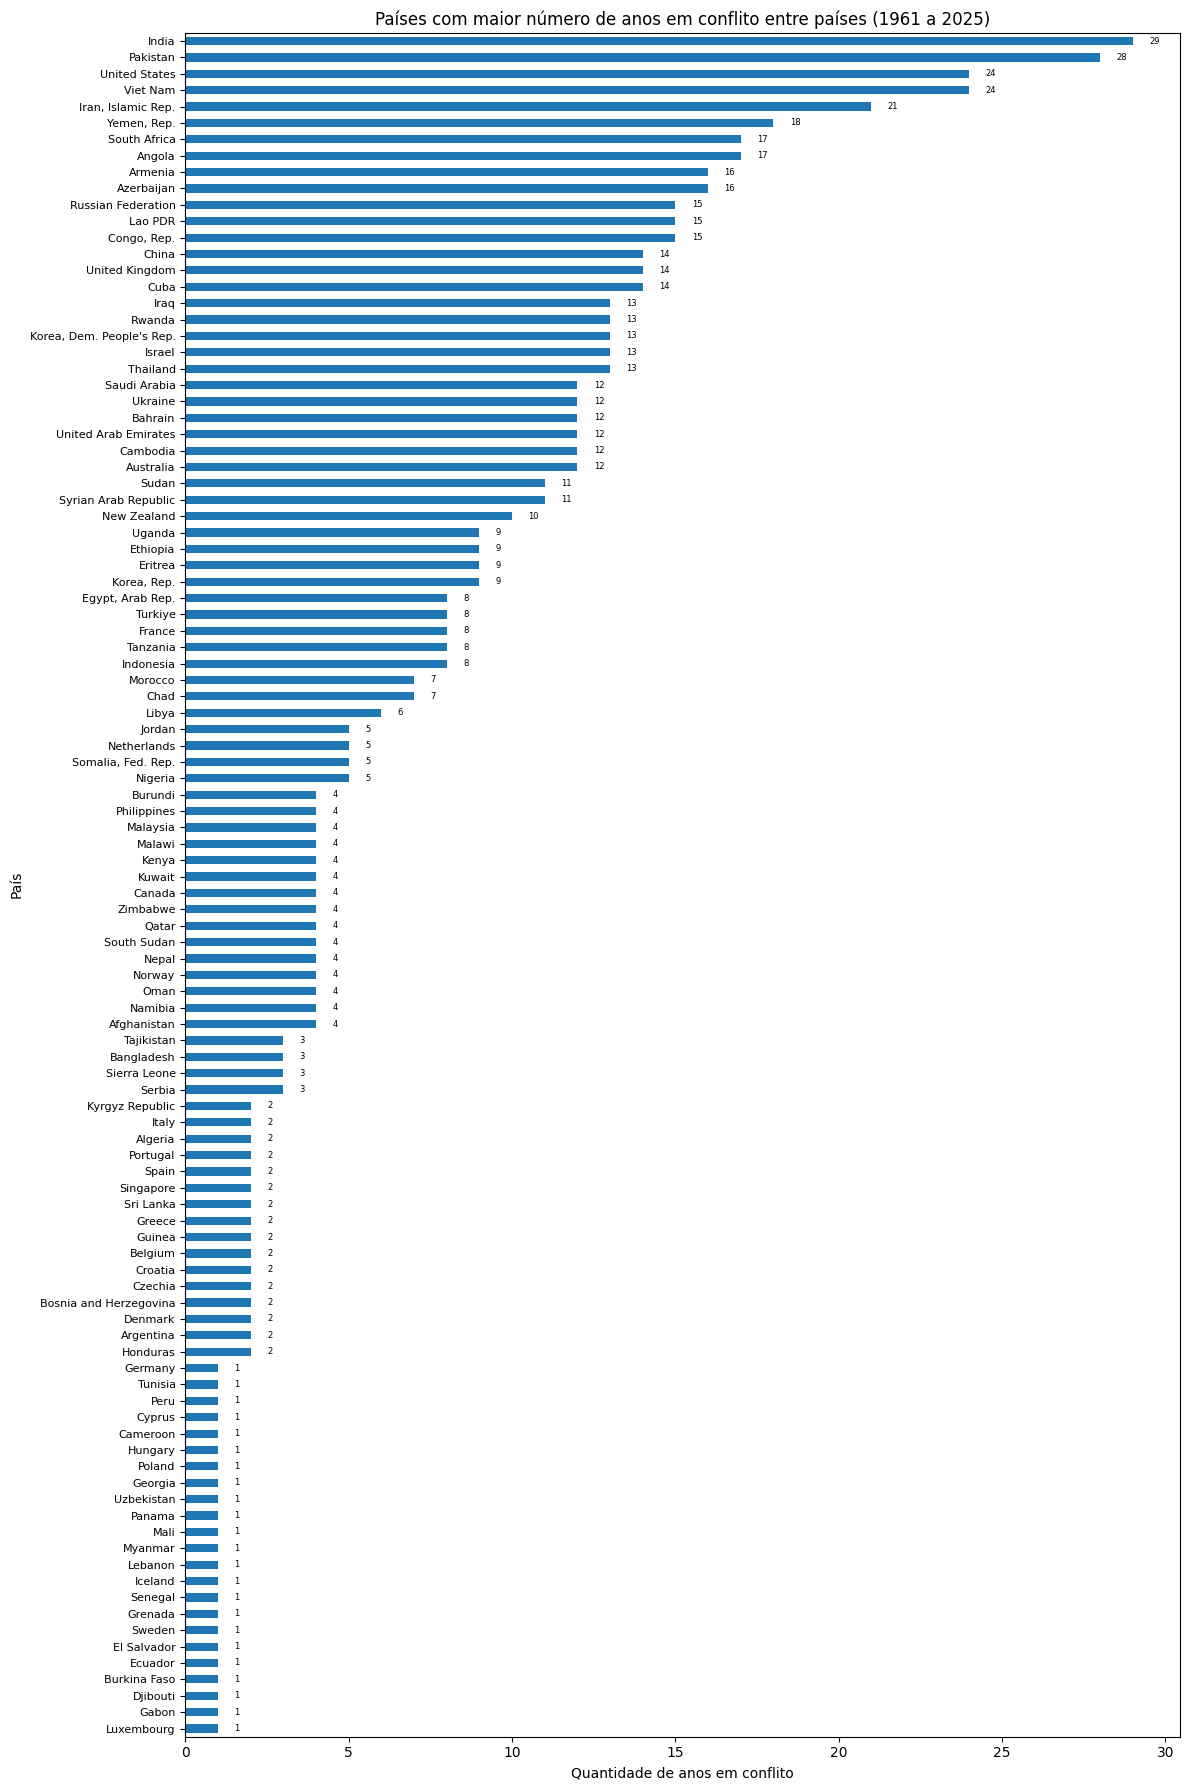

In [23]:
# Gráfico de quantidade de conflitos por países.
#contar a quantidade de conflitos por países
contagem = (df_base.groupby("Country Name")["Conflito (t+1)"].sum().sort_values(ascending=False))
#selecionar os países que tiveram pelo menos um conflito
contagem = contagem[contagem >= 1]
#Criar o gráfico
fig, ax = plt.subplots(figsize=(12, 18))

contagem.sort_values().plot(
    kind="barh",
    ax=ax
)
# Adiciona os valores nas barras
for i, valor in enumerate(contagem.sort_values()):
    ax.text(
        valor + 0.5,
        i,
        str(int(valor)),
        va="center",
        size=6
    )
plt.title("Países com maior número de anos em conflito entre países (1961 a 2025)")
plt.xlabel("Quantidade de anos em conflito")
plt.ylabel("País")

# Diminui o tamanho dos nomes dos países
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()


ANÁLISE:

*Por meio do gráfico, observa-se que os países asiáticos concentram a maior quantidade de conflitos, seguidos pelos países africanos.*

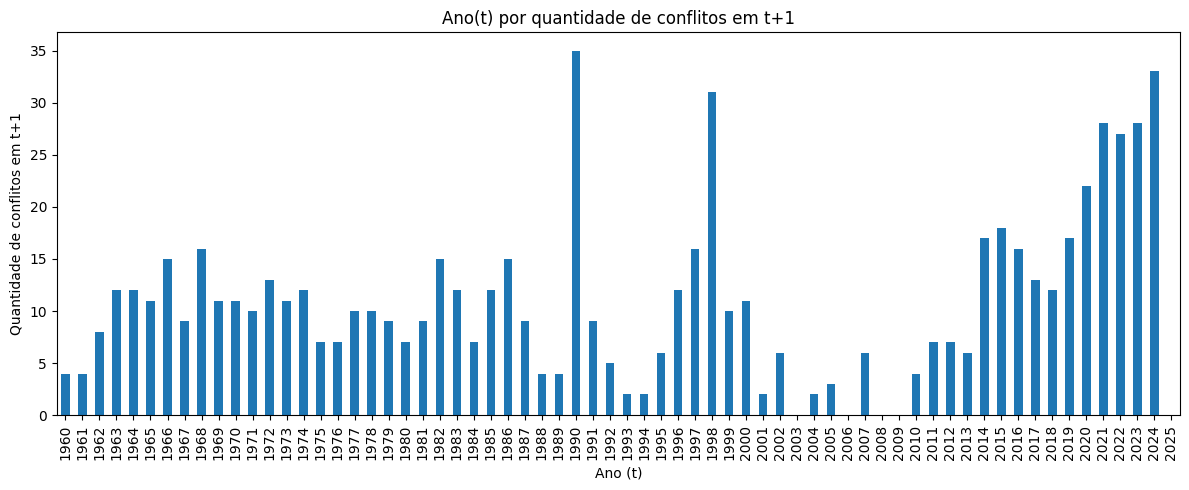

In [24]:
# Gráfico de quantidade de conflitos (t+1) por ano (t).

contagem_anos = (df_base.groupby("Ano")["Conflito (t+1)"].sum())



fig, ax = plt.subplots(figsize=(12, 5))

contagem_anos.plot(
    kind="bar",
    ax=ax
)

plt.title("Ano(t) por quantidade de conflitos em t+1")
plt.xlabel("Ano (t)")
plt.ylabel("Quantidade de conflitos em t+1")

plt.tight_layout()
plt.show()

ANÁLISE:

*É interessante observar que, até 2009, a quantidade de conflitos mundiais entre países não apresentava um padrão bem definido. Em alguns anos, como 1990 e 1998, a quantidade de conflitos em *t+1* foi significativamente superior à média do período.*

*Por outro lado, a partir de 2010, observa-se uma tendência de crescimento na quantidade de conflitos em *t+1*. O ano de 2025 não foi considerado nessa análise, pois não há dados disponíveis referentes a 2026, necessários para determinar a variável de resposta.*

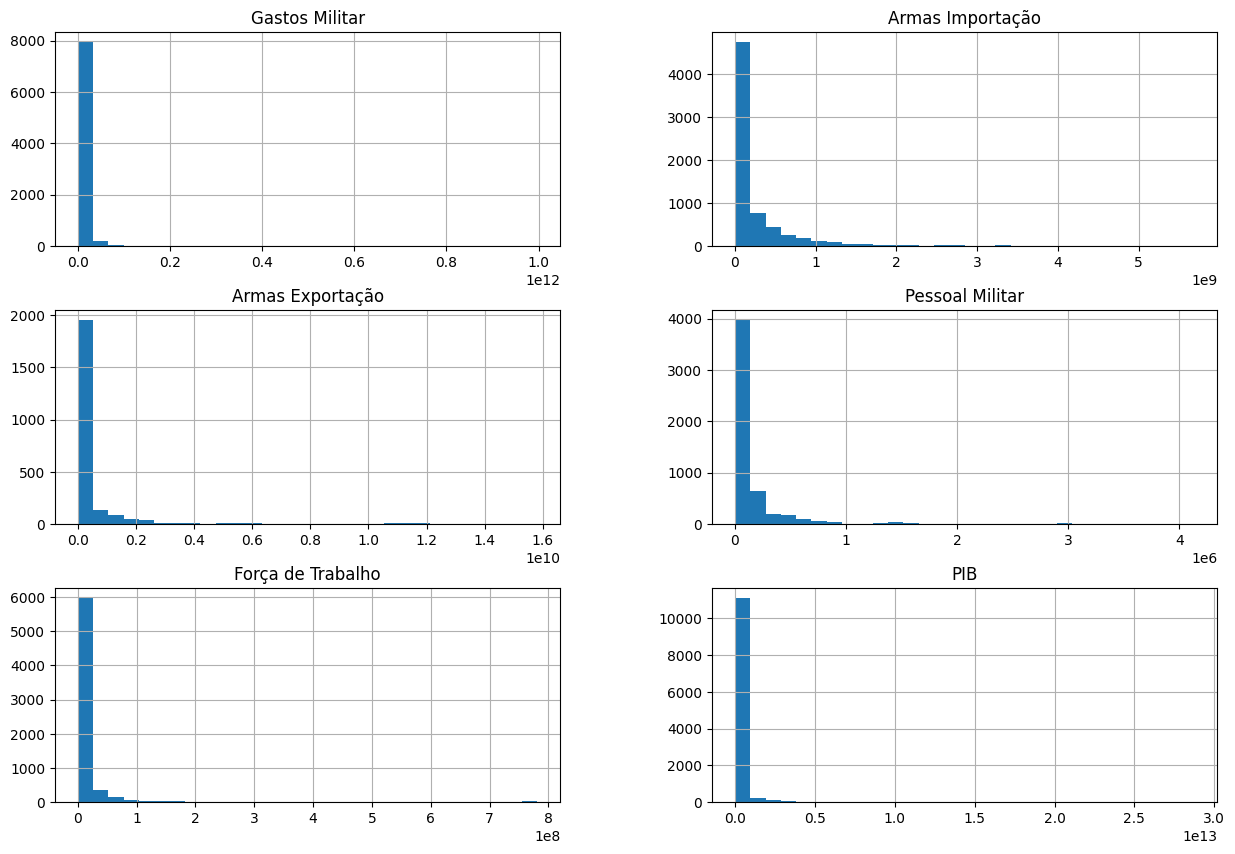

In [25]:
# Gráfico histograma dos parâmetros
num_cols = df_base.columns[3:-1]

df_base[num_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.show()

ANÁLISE:

*A distribuição dos daados dos atributos tem distribuição com assimetria positiva e alta dispersão.  Desta forma, é possível perceber que dados possuem uma tendência de se agrupar no início da curva, com uma frequência muito maior de valores menores. No entanto, a curva se estende por um longo intervalo, exibindo altas amplitudes devido à presença de valores esporádicos muito mais altos*

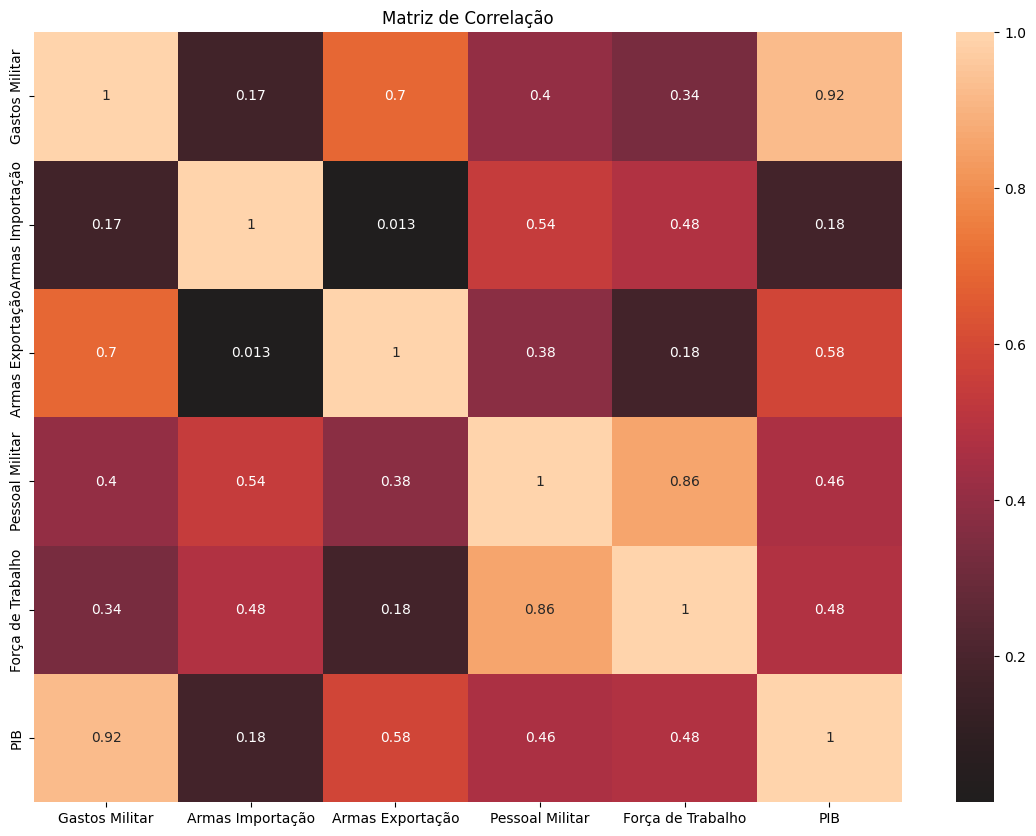

In [26]:
# Gráfico correlação
num_cols = df_base.columns[3:-1]

corr=df_base[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    center=0
)
plt.title("Matriz de Correlação")
plt.show()



Análise:

*Observa-se uma forte correlação entre os gastos militares e o PIB, bem como entre a força de trabalho e o efetivo das forças armadas.*

## 4.1 Síntese da análise exploratória

*A análise exploratória dos dados permitiu identificar algumas características importantes para o desenvolvimento do modelo. Inicialmente, observou-se que a variável alvo (participação em conflitos) apresenta desbalanceamento, com uma quantidade significativamente menor de registros de países envolvidos em conflitos em comparação aos países sem conflitos. Esse aspecto deve ser considerado durante a avaliação dos modelos, tornando métricas como F1-Score e Recall mais adequadas do que apenas a acurácia.*

*Também foi identificado que praticamente todos os indicadores utilizados apresentam valores ausentes em algum nível. Dessa forma, será necessário realizar um tratamento adequado desses dados para garantir a qualidade das informações utilizadas no treinamento dos modelos.*

*Outra observação relevante foi a concentração dos conflitos em determinadas regiões do mundo, principalmente na África e na Ásia. Esse resultado sugere que a inclusão de uma variável relacionada ao continente ou à região geográfica do país pode contribuir para aumentar o poder preditivo dos modelos, uma vez que fatores geográficos podem influenciar a ocorrência de conflitos.*

*Por fim, observou-se a existência de forte correlação (multicolinearidade) entre alguns indicadores. Dessa forma, será necessário adotar estratégias para reduzir seus efeitos, evitando distorções em modelos sensíveis à multicolinearidade.*



####4.1 Pré ajuste do dataframe após a análise exploratória

In [27]:
#Eliminar países que não possuíem nenhuma informação dos atributos
#selecionar as colunas
colunas= df_base.columns[3:-1]
#Selecionar os países com imformação
paises_validos = (df_base.groupby("Country Name")[colunas].apply(lambda x: x.notna().any().any()))
#eliminar os países sem informação do dataset
df_base = df_base[df_base["Country Name"].isin(paises_validos[paises_validos].index)]


In [28]:
#Incluir uma coluna continente
df_base["Continente"] = (df_base["Country Code"].apply(obter_continente))

In [29]:
#Incluir a Coluna "% Força Militar" utlizando dois atributos do dataset
df_base["% Força Militar"] = (df_base["Gastos Militar"]/df_base['PIB'])*100
#Eliminando as colunas Pessoaç militar e força de trabalho, pois as informações ja esrão contidas no atributo criado
df_base=df_base.drop(columns=['Gastos Militar','PIB'])


In [30]:
#Incluir a Coluna "% Força Militar" utlizando dois atributos do dataset
df_base["% gastos militares"] = (df_base["Pessoal Militar"]/df_base['Força de Trabalho'])*100
#Eliminando as colunas Pessoaç militar e força de trabalho, pois as informações ja esrão contidas no atributo criado
df_base=df_base.drop(columns=['Pessoal Militar','Força de Trabalho'])

ANÁLISE:

*Para preparar o *dataframe* para a separação entre os conjuntos de treino e teste, foram realizados alguns ajustes. Inicialmente, foram removidos os países que não possuíam informações para nenhum dos indicadores utilizados. Em seguida, foi adicionada a variável "Continente", considerando que a análise exploratória mostrou que determinadas regiões apresentam maior incidência de conflitos.*

*Posteriormente, os indicadores "Pessoal Militar" e "Força de Trabalho" foram combinados para gerar um novo atributo correspondente à proporção de militares em relação à força de trabalho. Essa transformação foi realizada devido à forte correlação entre essas variáveis e por representar um indicador mais adequado para a análise.*

*Da mesma forma, os indicadores "Gasto Militar" e "PIB" foram combinados para gerar um atributo correspondente ao percentual do PIB destinado aos gastos militares. Além de reduzir os efeitos da multicolinearidade, esse indicador permite comparar o esforço relativo de investimento militar entre países com diferentes tamanhos de economia.*

#5. Preparação dos dados e divisão treino/teste


In [31]:
# === Configuração do problema ===

#Informações do problema
TARGET = "Conflito (t+1)"
PROBLEM_TYPE = "classificacao com relacao de tempo"
ID_COLUMNS = ['Country Name']
DATE_COLUMN = 'Ano'
DROP_COLUMNS = ['Country Code']


columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS + [DATE_COLUMN])
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df_base.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)
print("Dado auxiliar:", DATE_COLUMN)



Tipo de problema: classificacao com relacao de tempo
Target: Conflito (t+1)
Número de features: 5
Features: ['Armas Importação', 'Armas Exportação', 'Continente', '% Força Militar', '% gastos militares']
Dado auxiliar: Ano


ANÁLISE:

*Embora o conjunto de dados possua uma dimensão temporal representada pelo ano, essa variável não será utilizada como feature do modelo. O ano será empregado apenas para realizar a divisão temporal entre treinamento e teste, garantindo que o modelo seja avaliado em observações futuras e reduzindo o risco de vazamento de informação.*

In [32]:
# === Divisão dos dados ===
# utilizado a divisão de treino e teste conforme séri temporal, pois os dados têm uma dependência temporal
#organizar o dataframe por data (do mais antigo para o mais recente)
df_sorted = df_base.sort_values(DATE_COLUMN).copy()
cutoff = int(len(df_sorted) * 0.8)
#Separr o treino referente ao 80% dos dados
train_df = df_sorted.iloc[:cutoff]
# teste 20% dos dados
test_df = df_sorted.iloc[cutoff:]
# separar o datafreme em atributos e alvo (o ano foi deixado como atributo para ajuste futuramente dos dados)
X_train = train_df[ID_COLUMNS+features].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[ID_COLUMNS+features].copy()
y_test = test_df[TARGET].copy()

print("Treino:", X_train.shape, "| Teste:", X_test.shape)


Treino: (11246, 6) | Teste: (2812, 6)


## 5.1 Justificativa da divisão

A divisão dos dados foi realizada de forma temporal, utilizando os anos mais antigos para treinamento do modelo e os anos mais recentes para teste. Essa estratégia foi escolhida porque o objetivo do trabalho é prever a ocorrência de conflitos futuros com base em informações históricas dos países. Dessa forma, a divisão temporal reproduz de maneira mais realista o cenário de utilização do modelo, no qual apenas informações do passado estão disponíveis para realizar previsões sobre eventos futuros.

Embora a variável alvo apresente desbalanceamento, com maior quantidade de registros sem conflitos do que com conflitos, não foi utilizada estratificação, pois a divisão temporal deve preservar a ordem cronológica dos dados. A utilização de uma divisão aleatória estratificada poderia misturar informações de períodos futuros no conjunto de treinamento, comprometendo a avaliação do modelo.




# 6. Pré-processamento e pipeline




In [33]:
#Tratar dados faltantes no conjunto de treinamento

#Incluir os valores mais proximos nos seguintes atributos

col_ajust =['% gastos militares', '% Força Militar']
X_train[col_ajust] = (X_train.groupby("Country Name")[col_ajust].ffill().bfill())

# dicionário de mediana por grupo
mediana_continente = {}

for col in col_ajust:
  #Para países que não tiverem falores nos atributos, será incluído a mediana do países do mesmo continente
  X_train[col] = (X_train.groupby("Continente")[col].transform(lambda x: x.fillna(x.median())))
  #Obter o valor da mediana para cada grupo
  mediana_continente[col] = (X_train.groupby("Continente")[col].median())


#Incluir zero nos seguintes atributos faltantes
X_train['Armas Importação'] =X_train['Armas Importação'].fillna(0)
X_train['Armas Exportação'] =X_train['Armas Exportação'].fillna(0)
# eliminar a coluna Country Name, que foi apenas utilizada para auxiliar a inclusão de valores faltantes
X_train = X_train.drop(columns=['Country Name'])


In [34]:
#Tratar dados faltantes no conjunto de treinamento

#Incluir os valores mais proximos nos seguintes atributos
col_ajust =['% gastos militares', '% Força Militar']
X_test[col_ajust] = (X_test.groupby("Country Name")[col_ajust].ffill().bfill())


for col in col_ajust:
  #Para países que não tiverem falores nos atributos, será incluído a mediana do países do mesmo continente obtivo pelo teste
  X_test[col] = X_test[col].fillna(X_test["Continente"].map(mediana_continente[col]))



#Incluir zero nos seguintes atributos faltantes
X_test['Armas Importação'] =X_test['Armas Importação'].fillna(0)
X_test['Armas Exportação'] =X_test['Armas Exportação'].fillna(0)

# eliminar a coluna Country Name, que foi apenas utilizada para auxiliar a inclusão de valores faltantes
X_test = X_test.drop(columns=['Country Name'])


In [35]:
# Identificação automática simples de colunas numéricas e categóricas.


num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("scaler", MinMaxScaler())
])

categorical_pipe = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")


print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['Armas Importação', 'Armas Exportação', '% Força Militar', '% gastos militares']
Colunas categóricas: ['Continente']


## 6.1 Decisões de pré-processamento

Os dados passaram por etapas de pré-processamento com o objetivo de melhorar sua qualidade e adequação aos modelos de classificação. Inicialmente, foi realizado o tratamento dos valores ausentes. Sempre que possível, optou-se por utilizar o valor disponível mais próximo para o mesmo país em anos anteriores, preservando a característica temporal da base de dados. Nos casos em que não havia informações históricas suficientes para esse preenchimento, foi utilizada a mediana dos países pertencentes ao mesmo continente. A mediana foi escolhida por ser menos sensível a valores extremos do que a média.

Para os indicadores "Armas Importação" e "Armas Exportação", optou-se por substituir todos os valores ausentes por zero, considerando que há maior probabilidade de esses países não terem realizado importações ou exportações de armamentos nos períodos sem dados disponíveis.

Há modelos que são sensíveis à escala das variáveis, sendo necessário realizar o escalonamento dos atributos numéricos. Para isso, foi utilizado o MinMaxScaler, que normaliza os dados para um intervalo entre 0 e 1, garantindo que todas as variáveis contribuam de forma equilibrada para o treinamento dos modelos. A variável categórica "Continente" foi transformada por meio da técnica One-Hot Encoding, permitindo sua utilização pelos algoritmos de classificação.

# 7. Baseline e modelos candidatos




In [36]:
# === Definição de baseline e modelos candidatos ===

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)


baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

#modelos candidatos
candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(class_weight="balanced",max_iter=2000, random_state=SEED))
    ]),

    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(class_weight="balanced",random_state=SEED))
    ]),

    "svm": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model",SVC(class_weight="balanced",random_state=SEED))
  ]),

    "xgb": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model",XGBClassifier(scale_pos_weight=scale_pos_weight,random_state=SEED,
      eval_metric="logloss"))
  ])
}


print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest', 'svm', 'xgb']


## 7.1 Justificativa dos modelos

O modelo baseline escolhido foi o DummyClassifier, utilizando a estratégia de prever sempre a classe majoritária. Essa escolha é coerente porque fornece uma referência mínima de desempenho, permitindo verificar se os demais modelos realmente conseguem aprender padrões relevantes nos dados e superar uma abordagem trivial.

Como modelos candidatos foram selecionados a Regressão Logística, SVM (Support Vector Machine), Random Forest e XGBoost. Esses algoritmos são amplamente utilizados em problemas de classificação binária e apresentam características distintas, permitindo comparar diferentes abordagens de aprendizado.






# 8. Treinamento e avaliação inicial



In [37]:
results = {}
trained_models = {}


# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)

proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    results[name] = evaluate_classification(y_test, y_pred, proba)


    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

show_results_table(results)


,precision,recall,f1,roc_auc,train_time_s
baseline,0.000000,0.000000,0.000000,0.500000,0.019
LogisticRegression,0.216837,0.711297,0.332356,0.827392,0.045
RandomForest,0.333333,0.004184,0.008264,0.727862,1.011
svm,0.217448,0.698745,0.331678,NaN,2.957
xgb,0.246753,0.158996,0.193384,0.669032,0.160


## 8.1 Análise dos resultados iniciais


*Os resultados demonstram que todos os modelos avaliados superaram o baseline, indicando que os indicadores militares utilizados possuem alguma capacidade de identificar padrões relacionados à ocorrência de conflitos futuros. Entretanto, os resultado demonstram que os modelos não conseguiram obter um bom desempenho.*

*A métrica principal utilizada foi o F1-Score, por ser mais adequada a problemas de classificação com classes desbalanceadas. Como a quantidade de países sem conflito é significativamente superior à quantidade de países em conflito, a métrica acurácia não foi utilizada, pois não trará um resultado relevante para a análisr. Além do F1-Score, também foram analisadas as métricas de precisão, recall e ROC AUC.*

*Entre os modelos avaliados, a Regressão Logística apresentou o melhor desempenho geral, alcançando o maior F1 e o maior recall. Isso indica que foi o modelo mais eficiente para identificar países que efetivamente participaram de conflitos no período analisado. Embora a precisão apresente um resultado baixo.*

*O SVM foi o segundo modelo com melhor desempenho, alcançando o segundo maior F1 e recall, os valores foram muito próximos dos resultados da regressão logistica. O Random Forest foi o modelo com pior desempenho.*

*Em relação ao tempo de treinamento, todos os modelos apresentaram desempenho computacional satisfatório. O modelo mais demorado é o SVM.*



# 9. Validação e otimização de hiperparâmetros




In [38]:
# === Otimização de hiperparâmetros ===



t0 = time.time()
# Parâmetros
param_grid = [

{
    "model__solver": ["liblinear"],
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
},

{
    "model__solver": ["lbfgs", "newton-cg"],
    "model__penalty": ["l2"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

]

model_to_tune=Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(class_weight="balanced",max_iter=2000, random_state=SEED))])

scoring = "f1"

if model_to_tune is not None:
    search = GridSearchCV(estimator=model_to_tune,
            param_grid=param_grid,
            scoring=scoring,
            cv=None,
            n_jobs=-1
            )

    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)

#tempo para o calculo dos hiperparâmetros
train_time_0 = time.time() - t0

Melhor score na validação: 0.14686404520510565
Melhores hiperparâmetros: {'model__C': 100, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


## 9.1 Discussão da otimização


Os melhores hiperparâmetros encontrados foram C = 100, class_weight = balanced, penalty = l2 e solver = lbfgs.

A busca foi limitada a um conjunto reduzido de combinações para manter o tempo de processamento adequado. Caso houvesse mais tempo, poderiam ser testados outros valores de C, além de diferentes solvers e tipos de regularização, para verificar se seria possível obter ganhos adicionais de desempenho.


# 10. Avaliação final no conjunto de teste




Modelo final: modelo_otimizado_LogisticRegression
              precision    recall  f1-score   support

         0.0       0.97      0.76      0.85      2573
         1.0       0.22      0.72      0.33       239

    accuracy                           0.76      2812
   macro avg       0.59      0.74      0.59      2812
weighted avg       0.90      0.76      0.81      2812



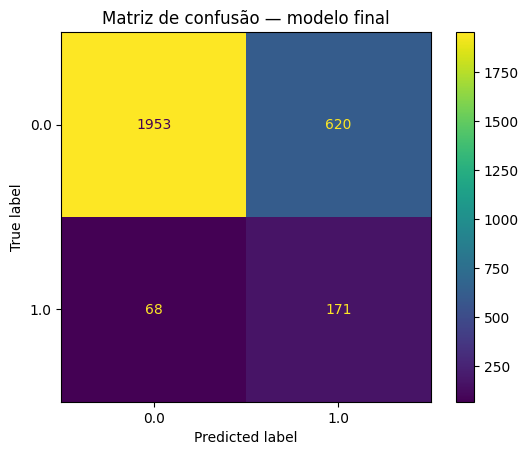

In [39]:
# === Avaliação final ===
train_time = time.time() - t0

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado_LogisticRegression"
elif trained_models:

    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)


y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Matriz de confusão — modelo final")
plt.show()
results[final_model_name] = evaluate_classification(y_test, y_pred, proba)
#tempo de exercução do modelo
train_time = time.time() - t0 + train_time_0
results[final_model_name]["train_time_s"] = round(train_time, 3)

## 10.1 Análise de erros e limitações
*A otimização de parâmetros não trouxe um resultado melhor que o resultado anterior obtido pela regressão logistica. Os resultados foram muito parecidos, porém houve uma gasto computacional para obter esse resultado.*

*A matriz de confusão obtida pela otimização de parâmetros demonstra que o modelo foi capaz de identificar aproximadamente dois terços dos conflitos observados no conjunto de teste, apresentando um recall elevado para a classe de interesse. Por outro lado, o número de falsos positivos permaneceu relativamente alto, indicando que parte significativa dos alertas emitidos pelo modelo não se concretizou em conflitos reais. Considerando o objetivo de identificar possíveis países com risco de participação em conflitos, esse comportamento é aceitável, pois prioriza a detecção dos casos positivos em detrimento da redução dos falsos alarmes.*

#11. Novas estratégias de melhorias dos resultados

##11.1 Incluir dados sintéticos nos dados de treino para balancear os dados

In [40]:
#Necessidade de trasformar os dados categóricos em numéricos
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# Aprende apenas no treino
encoder.fit(X_train[cat_cols])

# Transforma treino e teste usando o mesmo encoder
X_train_encoded = encoder.transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

# Criar DataFrames
colunas = encoder.get_feature_names_out(cat_cols)

X_train_cat = X_train[num_cols].copy()
X_train_cat[colunas] = X_train_encoded

X_test_cat = X_test[num_cols].copy()
X_test_cat[colunas] = X_test_encoded



In [41]:
# utilizar o smote para criar dados sintéticos
smote = SMOTE(random_state=42)


X_train_bal,y_train_bal = smote.fit_resample(
    X_train_cat,
    y_train
)

##11.2 Pré-processamento e pipeline

In [42]:
#Ajustes para os modelos
num_cols = X_train_bal.columns.tolist()
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
], remainder="drop")


##11.3 Novos modelos

In [43]:
#Novos modelos candidatos
candidates = {
    "LogisticRegression_2": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED))
    ]),

    "RandomForest_2": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ]),

    "svm_2": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model",SVC(random_state=SEED))
  ]),

    "xgb_2": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model",XGBClassifier(random_state=SEED,
      eval_metric="logloss"))
  ])
}

##11.4 Treinamento e Avaliação dos Novos Modelos

In [44]:
#treinando os novos modelos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train_bal, y_train_bal)
    train_time = time.time() - t0

    y_pred = model.predict(X_test_cat)

    proba = model.predict_proba(X_test_cat) if hasattr(model, "predict_proba") else None
    results[name] = evaluate_classification(y_test, y_pred, proba)


    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model


In [45]:
show_results_table(results)

,precision,recall,f1,roc_auc,train_time_s
baseline,0.000000,0.000000,0.000000,0.500000,0.019
LogisticRegression,0.216837,0.711297,0.332356,0.827392,0.045
RandomForest,0.333333,0.004184,0.008264,0.727862,1.011
svm,0.217448,0.698745,0.331678,NaN,2.957
xgb,0.246753,0.158996,0.193384,0.669032,0.160
modelo_otimizado_LogisticRegression,0.216182,0.715481,0.332039,0.669032,174.258
LogisticRegression_2,0.212794,0.682008,0.324378,0.828963,0.032
RandomForest_2,0.207031,0.221757,0.214141,0.737326,2.998
svm_2,0.320755,0.355649,0.337302,NaN,6.678
xgb_2,0.220000,0.276151,0.244898,0.706250,0.205


## 11.5. Validação e otimização de hiperparâmetros

In [46]:
# === Otimização de hiperparâmetros ===

t0 = time.time()




param_grid = [

{
    "model__solver": ["liblinear"],
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
},

{
    "model__solver": ["lbfgs", "newton-cg"],
    "model__penalty": ["l2"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

]

model_to_tune=Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(class_weight="balanced",max_iter=2000, random_state=SEED))])

scoring = "f1"

if model_to_tune is not None:
    search = GridSearchCV(estimator=model_to_tune,
            param_grid=param_grid,
            scoring=scoring,
            cv=None,
            n_jobs=-1
            )

    search.fit(X_train_bal, y_train_bal)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)

train_time_0 = time.time() - t0

Melhor score na validação: 0.7132451640136291
Melhores hiperparâmetros: {'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


##11.6 Avaliação Final

Modelo final: modelo_otimizado_LogisticRegression_2
              precision    recall  f1-score   support

         0.0       0.97      0.76      0.85      2573
         1.0       0.22      0.70      0.33       239

    accuracy                           0.76      2812
   macro avg       0.59      0.73      0.59      2812
weighted avg       0.90      0.76      0.81      2812



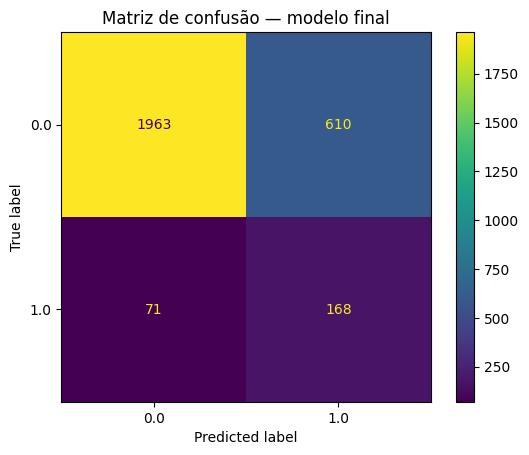

In [47]:
# === Avaliação final ===
train_time = time.time() - t0

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado_LogisticRegression_2"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)


y_pred = final_model.predict(X_test_cat)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(final_model, X_test_cat, y_test)
plt.title("Matriz de confusão — modelo final")
plt.show()

results[final_model_name] = evaluate_classification(y_test, y_pred, proba)

train_time = time.time() - t0 + train_time_0
results[final_model_name]["train_time_s"] = round(train_time, 3)

ANÁLISE:

*Conforme ocorreu nos modelos sem o smoote, a otimização de parâmetros não ocasinou uma melhora no resultado, apresentando resultados muito parecidos com o modelo original.*


In [48]:
#Resultado Final
show_results_table(results)

,precision,recall,f1,roc_auc,train_time_s
baseline,0.000000,0.000000,0.000000,0.500000,0.019
LogisticRegression,0.216837,0.711297,0.332356,0.827392,0.045
RandomForest,0.333333,0.004184,0.008264,0.727862,1.011
svm,0.217448,0.698745,0.331678,NaN,2.957
xgb,0.246753,0.158996,0.193384,0.669032,0.160
modelo_otimizado_LogisticRegression,0.216182,0.715481,0.332039,0.669032,174.258
LogisticRegression_2,0.212794,0.682008,0.324378,0.828963,0.032
RandomForest_2,0.207031,0.221757,0.214141,0.737326,2.998
svm_2,0.320755,0.355649,0.337302,NaN,6.678
xgb_2,0.220000,0.276151,0.244898,0.706250,0.205


Análise:

*As modificações realizadas utlizando o smoote não produziram ganhos significativos de desempenho. Embora alguns modelos, como Random Forest e XGBoost, tenham apresentado melhorias em relação às suas versões iniciais, seus resultados permaneceram inferiores aos da Regressão Logística. O SVM apresentou um pequeno aumento no F1-Score, porém acompanhado de uma redução expressiva no Recall, característica indesejável para este problema, cujo objetivo é maximizar a identificação de países que entrarão em conflito. Dessa forma, a Regressão Logística em sua configuração inicial permaneceu como o modelo mais equilibrado, apresentando o melhor resultado entre Recall e F1-Score.*

# 12. Comparação final dos modelos



| Modelo | Precision | Recall | F1 | ROC AUC | Tempo de treino (s) | Observações |
|----------|----------:|----------:|----------:|----------:|----------:|----------|
| baseline | 0.000000 | 0.000000 | 0.000000 | 0.500000 | 0.019 | Modelo de referência que prevê apenas a classe majoritária. |
| LogisticRegression | 0.216837 | 0.711297 | 0.332356 | 0.827392 | 0.045 | Melhor equilíbrio entre recall, F1 e ROC AUC. |
| RandomForest | 0.333333 | 0.004184 | 0.008264 | 0.727862 | 1.011 | Melhor precisão, mas identifica pouquíssimos conflitos. |
| svm | 0.217448 | 0.698745 | 0.331678 | NaN | 2.957 | Desempenho semelhante à Regressão Logística, porém mais lento. |
| xgb | 0.246753 | 0.158996 | 0.193384 | 0.669032 | 0.160 | Recall relativamente baixo. |
| modelo_otimizado_LogisticRegression | 0.216182 | 0.715481 | 0.332039 | 0.669032 | 174.258 | Otimização aumentou pouquissimo o recall, mas sem ganho relevante em F1. |
| LogisticRegression_2 | 0.212794 | 0.682008 | 0.324378 | 0.828963 | 0.032 | Maior ROC AUC da comparação e menor tempo de treino, porém diminuiu o F1. |
| RandomForest_2 | 0.207031 | 0.221757 | 0.214141 | 0.737326 | 2.998 | Recall superior ao RandomForest original, mas F1 ainda baixo. |
| svm_2 | 0.320755 | 0.355649 | 0.337302 | NaN | 6.678 | Maior F1-score entre todos os modelos avaliados, porém recall baixo. |
| xgb_2 | 0.220000 | 0.276151 | 0.244898 | 0.706250 | 0.205 | Melhor equilíbrio que o xgb original. |
| modelo_otimizado_LogisticRegression_2 | 0.215938 | 0.702929 | 0.330383 | 0.706250 | 11.911 | Desempenho próximo ao LogisticRegression, com maior custo computacional. |



# 13. Conclusão
## 13.1 Repondendo as hipoteses:


1. _Indicadores relacionados à capacidade militar dos países, como gastos militares, efetivo das forças armadas, importação e exportação de armamentos, possuem relação com a ocorrência de conflitos e podem ser utilizados para prever a participação de um país em conflitos no ano seguinte._

*Os resultados obtidos fornecem evidências favoráveis a essa hipótese. Os modelos de Machine Learning foram capazes de identificar padrões nos dados históricos e apresentar desempenho superior ao modelo baseline, indicando que os indicadores militares utilizados possuem capacidade preditiva. Entretanto, os resultados também sugerem que essas variáveis não explicam completamente a ocorrência de conflitos, uma vez que os valores de F1-score ainda se mantiveram moderados.*


2. _Modelos de Machine Learning são capazes de identificar padrões nos dados históricos e apresentar desempenho superior a uma classificação aleatória ou a um modelo baseline simples._

*Essa hipótese foi confirmada. O modelo baseline apresentou F1-score igual a 0 e ROC AUC de 0,5, caracterizando uma classificação sem capacidade discriminatória. Em contrapartida, os modelos de Machine Learning alcançaram F1-scores superiores a 0,33 e valores de ROC AUC próximos de 0,83, demonstrando capacidade de identificar padrões relevantes nos dados.*

3. _Algoritmos mais robustos, como Random Forest e XGBoost, apresentarão melhor desempenho preditivo do que modelos mais simples, como SVM._

*Essa hipótese não foi confirmada. Os resultados mostraram que os modelos baseados em árvores apresentaram desempenho inferior aos modelos de Regressão Logística e SVM. Além disso, o ganho obtido pelo SVM em relação à Regressão Logística foi praticamente nulo em termos de F1-score, enquanto a Regressão Logística apresentou recall significativamente superior e menor tempo de processamento. Dessa forma, os resultados indicam que modelos mais complexos não necessariamente produzem melhores resultados para este problema e conjunto de dados.*




##13.2 Análise Final


*O objetivo deste trabalho foi desenvolver um modelo de Machine Learning capaz de prever a participação de países em conflitos no ano seguinte a partir de indicadores relacionados à capacidade militar, incluindo gastos militares, efetivo das forças armadas, importação e exportação de armamentos.*

*Os resultados demonstraram que os modelos avaliados foram capazes de identificar padrões relevantes nos dados históricos e superar significativamente o desempenho do modelo baseline. O baseline apresentou F1-score igual a 0 e ROC AUC de 0,5, enquanto os melhores modelos alcançaram F1-scores próximos de 0,33 e ROC AUC superior a 0,82.
Embora o modelo SVM_2 tenha obtido o maior F1-score (0,337302), a diferença em relação à Regressão Logística (0,332356) foi muito pequena, representando praticamente um empate em termos de desempenho preditivo. Considerando também o recall, a capacidade discriminatória e o custo computacional, a Regressão Logística foi considerada a melhor solução encontrada. O modelo apresentou recall de 0,711297, ROC AUC de 0,827392 e tempo de treinamento de apenas 0,045 segundos, demonstrando melhor capacidade de identificar países que participarão de conflitos futuros com baixo custo computacional.*

*Por meio do estudo foi verificar que indicadores militares possuem capacidade para auxiliar na previsão de conflitos, mas não são suficientes para gerar um modelo com resultados relevantes para tomada de decisões reais.*

*Como trabalhos futuros, pretendese ampliar o conjunto de atributos utilizados pelos modelos, incorporando informações como estabilidade política, regime de governo e entre outros. Adicionalmente, pretende-se realizar uma etapa de clusterização dos países, agrupando-os de acordo com características militares, econômicas, políticas e geográficas. Essa abordagem poderá auxiliar na identificação de padrões específicos entre grupos de países semelhantes e contribuir para o desenvolvimento de modelos mais especializados e precisos para a previsão de conflitos futuros.*